In [2]:
#impoting the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import torch
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Understanding

Setting up the path to data

In [5]:
from pathlib import Path
data_path = Path('/content/drive/MyDrive')
image_path = data_path / '/content/drive/MyDrive'
train_dir = image_path/'/content/drive/MyDrive/train'
valid_dir = image_path/'/content/drive/MyDrive/valid'
test_dir = Path("/content/drive/MyDrive/test")

In [6]:
from torchvision import datasets, transforms # Make sure 'transforms' is imported

# Define your transforms with consistent resizing
transforms_train = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize all images to 256x256
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),  # Apply ToTensor transform
    # ... other transforms ...
])
transforms_valid = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize all images to 256x256
    transforms.ToTensor(),  # Apply ToTensor transform
    # ... other transforms ...
])

# Apply the transforms to your dataset
train_data = datasets.ImageFolder(root=train_dir, transform=transforms_train)
valid_data = datasets.ImageFolder(root=valid_dir, transform=transforms_valid)



In [7]:
train_data = datasets.ImageFolder(root=train_dir,transform=transforms.ToTensor())
valid_data = datasets.ImageFolder(root=valid_dir,transform=transforms.ToTensor())

In [8]:
class_names = train_data.classes
class_names

['Apple_Black_rot',
 'Apple_Cedar_apple_rust',
 'Apple_healthy',
 'Apple_scab',
 'Blueberry_healthy',
 'Cherry_(including_sour)_Powdery_mildew',
 'Cherry_(including_sour)_healthy',
 'Corn_(maize)_Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)_Common_rust_',
 'Corn_(maize)_Northern_Leaf_Blight',
 'Corn_(maize)_healthy',
 'Grape_Black_rot',
 'Grape_Esca_(Black_Measles)',
 'Grape_Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape_healthy',
 'Mango_Bacterial Canker',
 'Orange_Haunglongbing_(Citrus_greening)',
 'Peach_Bacterial_spot',
 'Peach_healthy',
 'Pepper_Bacterial_spot',
 'Pepper_healthy',
 'Potato_Early_blight',
 'Potato_Late_blight',
 'Potato_healthy',
 'Raspberry_healthy',
 'Soybean_healthy',
 'Squash_Powdery_mildew',
 'Strawberry_Leaf_scorch',
 'Strawberry_healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Healthy',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites Two-spotted_spider_mite',
 'Tomato_Target_Spot',
 'T

In [9]:
print(f"It has {len(train_data.classes)} classes")

It has 56 classes


In [10]:
print(f"Number of images in train data: {len(train_data)}")
print(f"Number of images in valid data: {len(valid_data)}")

Number of images in train data: 2952
Number of images in valid data: 2382


### Checking for class imbalances

In [11]:
import os
len(os.listdir(train_dir))

56

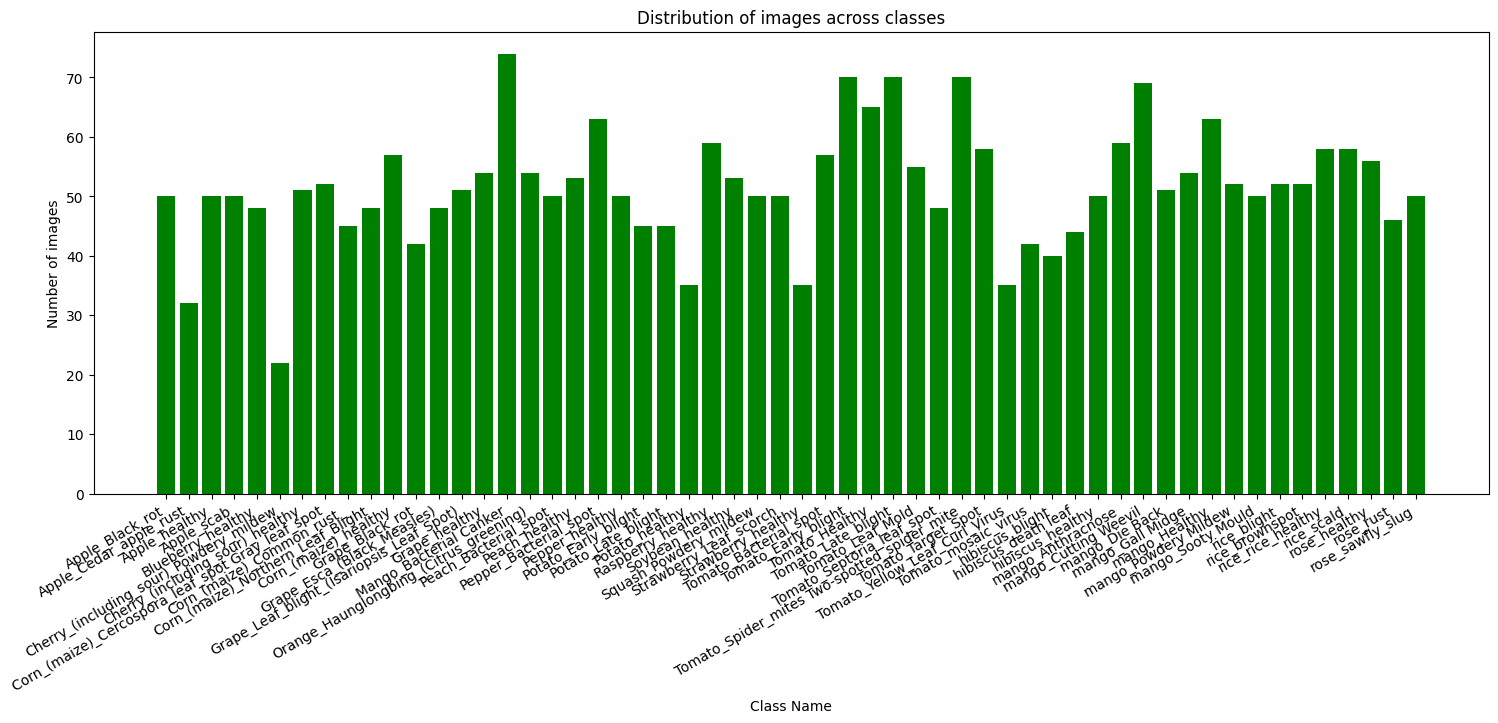

In [12]:
import os

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir,class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(18,6))
plt.bar(classes,counts,color='green')
plt.xlabel('Class Name')
plt.ylabel('Number of images')
plt.title("Distribution of images across classes")
plt.xticks(rotation=30,ha='right')
plt.show()

**Conclusion**: The number of images across all the classes are fairly similar and there are no class imbalances

In [13]:
import random
from PIL import Image
random.seed(9)

# Update glob pattern to search for image files within the 'images.jpg' directory
image_path_list = list(image_path.glob("images.jpg/*.jpg"))

# If no images are found, search for them in the 'image_path' folder
if not image_path_list:
    image_path_list = list(image_path.glob("*.jpg"))

# Continue with opening and displaying images only if images are found
if image_path_list:
    random_image_path = random.choice(image_path_list)
    image_class = random_image_path.parent.stem
    img = Image.open(random_image_path)
    print(f"Image Class: {image_class}")
    print(f"Image height: {img.height}")
    print(f"Image width: {img.width}")
    img
else:
    print("No .jpg image files found in the specified paths.")

Image Class: images
Image height: 256
Image width: 256


Image Class: rose_sawfly_slug
Image height: 256
Image width: 256


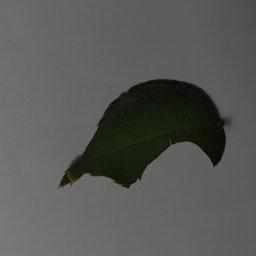

In [14]:
import random
from PIL import Image
random.seed(50)
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Image Class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

In [15]:
from torchvision import transforms

# Define mean and std before using them
mean = [0.500, 0.456, 0.406]  # Example values, adjust as needed
std = [0.229, 0.224, 0.225]  # Example values, adjust as needed

# Define your transforms with consistent resizing
transforms = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize all images to 256x256
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean, std=std)  # Now mean and std are defined
])

# Apply the transforms to your dataset
train_data = datasets.ImageFolder(root=train_dir, transform=transforms)
test_data = datasets.ImageFolder(root=valid_dir, transform=transforms)

# ... (rest of your code) ...

In [16]:
from torchvision import transforms

# Define your transforms with consistent resizing
transforms = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize all images to 256x256
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.02, contrast=0),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean, std=std)
])

# Apply the transforms to your dataset
train_data = datasets.ImageFolder(root=train_dir, transform=transforms)
test_data = datasets.ImageFolder(root=valid_dir, transform=transforms)

# ... (rest of your code) ...

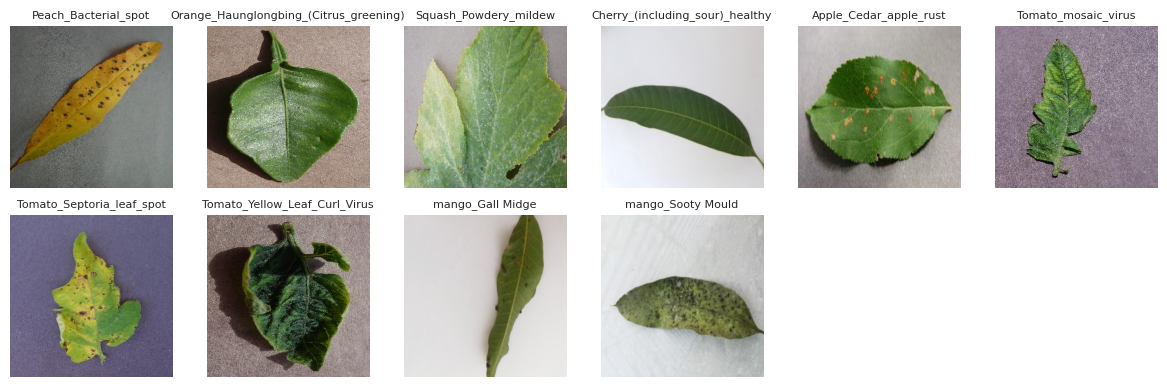

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import seaborn as sns

def visualize_dataset_images(dataset, num_images=10):
    sns.set(style="whitegrid")

    # Dynamically calculate grid dimensions
    num_cols = 6  #adjust this for a different aspect ratio
    num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division

    # Adjust figure size
    figsize = (num_cols * 2, num_rows * 2)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=figsize)

    # Load images and labels
    dataloader = DataLoader(dataset, batch_size=num_images, shuffle=True)
    images, labels = next(iter(dataloader))

    axs = axs.flatten()  # Flatten axes array for easier indexing
    for idx, img in enumerate(images):
        if idx >= num_images:
            break
        axs[idx].imshow(np.clip(img.numpy().transpose(1, 2,0 ), 0, 1))
        axs[idx].axis('off')
        axs[idx].set_title(f"{dataset.classes[labels[idx]]}", fontsize=8)

    # Remove unused axes
    for idx in range(len(images), len(axs)):
        fig.delaxes(axs[idx])

    plt.tight_layout()
    plt.show()


visualize_dataset_images(train_data)

### Transformations
1) Resizing all the image to 256 x 256 for consistent dimensions
2) Random Horizontal/Vertivcal Flips to make it robust to orientation changes
3) Color Jitter for making it robust against lighting conditions
4) Normalization for better data integrity

In [18]:
from torchvision import transforms

transform_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [19]:
transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)

In [20]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)
])

## Creating Dataloaders

In [21]:
from sklearn.utils.class_weight import compute_class_weight


In [22]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform = transforms)
test_data = datasets.ImageFolder(root=valid_dir,transform = transforms)

In [23]:
import os
BATCH_SIZE = 50
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_data,
                            batch_size = BATCH_SIZE,
                            shuffle=False,
                            num_workers = NUM_WORKERS)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fa7e4bb4d50>,
 <torch.utils.data.dataloader.DataLoader at 0x7fa8fa771310>)

In [24]:
# Get one batch of data
images, labels = next(iter(train_dataloader))

# Print batch size
print("Batch size:", images.shape[0])  # Should print: Batch size: 128

# Print image dimensions
print("Image shape:", images.shape)  # Example output: torch.Size([128, 3, 224, 224])

# Print labels
print("Labels:", labels[:10])  # Shows first 10 labels in batch


Batch size: 50
Image shape: torch.Size([50, 3, 256, 256])
Labels: tensor([37, 15,  7,  1, 25, 15, 50, 13,  9, 51])


## Device agnostics

In [25]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
# creating trian_test loops
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [27]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [28]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [29]:
class PlantDiseaseNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels = 3,out_channels = 32,kernel_size =3,padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels = 32,out_channels =64 , kernel_size = 3,padding =1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels = 64,out_channels = 128,kernel_size = 3,padding =1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels = 128,out_channels=256,kernel_size = 3,padding = 1 ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size = 3,padding = 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = 8*8*256,out_features = 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=1024,out_features = len(class_names))
        )
    def forward(self,x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.classifier(x)
        return x

In [30]:
!pip install torchinfo

In [31]:
model = PlantDiseaseNN().to(device)

In [32]:
# @title
from torchinfo import summary
summary(model,input_size=[1,3,256,256])

Layer (type:depth-idx)                   Output Shape              Param #
PlantDiseaseNN                           [1, 56]                   --
├─Sequential: 1-1                        [1, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 256, 256]         64
│    └─ReLU: 2-3                         [1, 32, 256, 256]         --
│    └─MaxPool2d: 2-4                    [1, 32, 128, 128]         --
├─Sequential: 1-2                        [1, 64, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 128, 128]         128
│    └─ReLU: 2-7                         [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-8                    [1, 64, 64, 64]           --
├─Sequential: 1-3                        [1, 128, 32, 32]          --
│    └─Conv2d: 2-9                       [1, 128, 64, 64]          73,856
│    

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(),lr=0.0001,weight_decay=0.01)

In [47]:
from timeit import default_timer as timer
start_time = timer()
model_results = train(model=model,train_dataloader=train_dataloader,test_dataloader=test_dataloader,optimizer=optimizer,loss_fn=loss_fn,epochs=10)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6961 | train_acc: 0.7833 | test_loss: 4.8453 | test_acc: 0.3542
Epoch: 2 | train_loss: 0.7115 | train_acc: 0.7843 | test_loss: 4.9013 | test_acc: 0.3254
Epoch: 3 | train_loss: 0.6514 | train_acc: 0.7983 | test_loss: 5.0734 | test_acc: 0.3546
Epoch: 4 | train_loss: 0.4972 | train_acc: 0.8427 | test_loss: 5.4319 | test_acc: 0.3454
Epoch: 5 | train_loss: 0.6074 | train_acc: 0.8137 | test_loss: 5.7414 | test_acc: 0.3312
Epoch: 6 | train_loss: 0.4948 | train_acc: 0.8320 | test_loss: 5.5466 | test_acc: 0.3408
Epoch: 7 | train_loss: 0.3890 | train_acc: 0.8747 | test_loss: 5.8295 | test_acc: 0.3683
Epoch: 8 | train_loss: 0.3690 | train_acc: 0.8873 | test_loss: 5.5925 | test_acc: 0.3617
Epoch: 9 | train_loss: 0.4220 | train_acc: 0.8617 | test_loss: 5.9142 | test_acc: 0.3337
Epoch: 10 | train_loss: 0.4662 | train_acc: 0.8353 | test_loss: 6.1709 | test_acc: 0.3462
Total training time: 378.188 seconds


In [48]:
import shutil

torch.save(model.state_dict(), '/content/drive/MyDrive/trained model/save_model/save_model_01')

# shutil.move('save_model_01', '/content/drive/MyDrive/trained model/save_model/save_model_01')  # Remove this line

In [49]:
saved_model = PlantDiseaseNN().to(device)
torch.save(model.state_dict(), '/content/drive/MyDrive/trained model/save_model/save_model_01')

saved_model.eval()

PlantDiseaseNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1

## Evaluation of model

In [50]:
def plot_loss_curves(results: dict[str, list[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

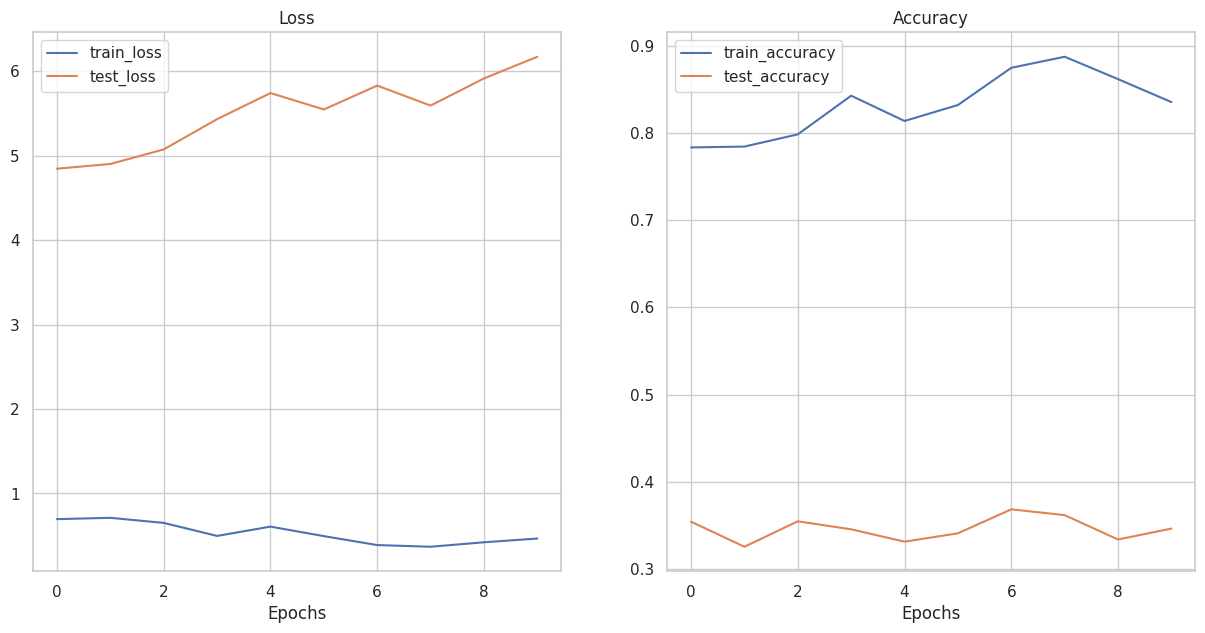

In [51]:
plot_loss_curves(model_results)

No signs of overfitting.

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import torch

def evaluate(model: torch.nn.Module,
             dataloader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module,
             device: torch.device):
    # To store predictions and true labels for calculating the metrics
    all_preds = []
    all_labels = []

    # Variable to accumulate total correct predictions for accuracy
    correct_preds = 0
    total_preds = 0

    # Evaluate the model using the existing test_step function and collect predictions
    model.eval()  # Switch model to evaluation mode

    # Disable gradient calculation for inference
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            # Move data to the device
            X, y = X.to(device), y.to(device)

            # Get model predictions using test_step
            test_pred_logits = model(X)

            # Get predicted class labels
            test_pred_labels = test_pred_logits.argmax(dim=1)

            # Store predictions and true labels
            all_preds.extend(test_pred_labels.cpu().numpy())  # move to CPU for metrics calculation
            all_labels.extend(y.cpu().numpy())

            # Calculate correct predictions for accuracy
            correct_preds += (test_pred_labels == y).sum().item()
            total_preds += len(y)

    # Calculate accuracy
    accuracy = correct_preds / total_preds

    # Calculate the precision, recall, and f1-score
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return accuracy, precision, recall, f1, cm

In [53]:
accuracy, precision, recall, f1, cm = evaluate(saved_model, test_dataloader, loss_fn, device)


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.0160
Precision: 0.0003
Recall: 0.0160
F1-score: 0.0005


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


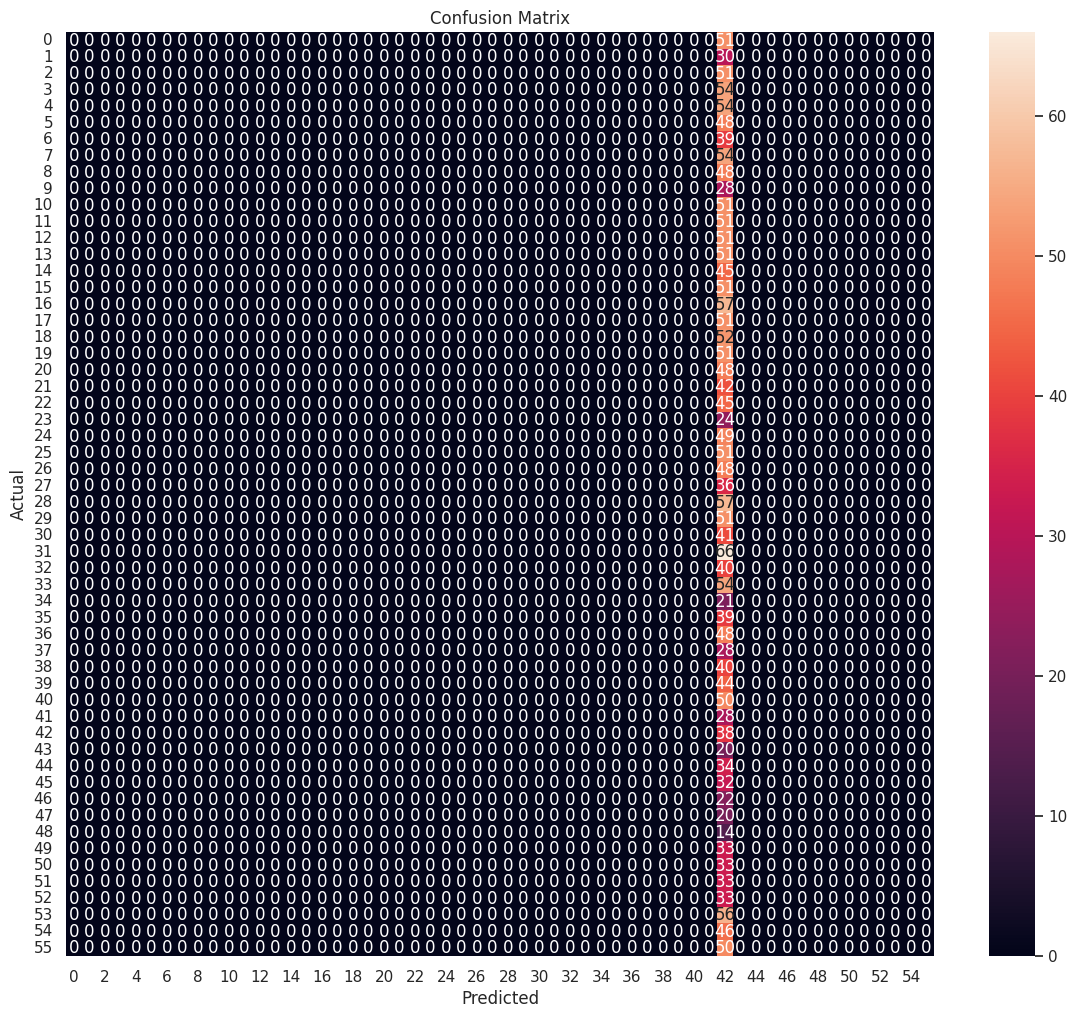

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# y_true: actual labels, y_pred: predicted labels
# The confusion matrix 'cm' has already been calculated in the previous cell
# using the evaluate function and the actual and predicted labels.
# We will use the 'cm' variable directly for plotting.
# cm = confusion_matrix(y_true, y_pred) # Remove this line as cm is already calculated

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Evaluation on actual test set.


In [55]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms

image_size = (256, 256)  # Specify the desired image size
preprocess = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)  # Ensure mean/std are defined
])

model.eval()
img, label = valid_data[0]

# Resize the image to the correct input size for the model
img = transforms.Resize(image_size)(img)

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    print(f"True label: {label}, Predicted: {pred.argmax(1).item()}")

True label: 0, Predicted: 32


In [56]:
# In cell ipython-input-35-aa90af17ebdf

# ... (previous imports and code) ...
from torchvision import transforms # Make sure transforms is imported

image_size = (256, 256)
# Redefine "preprocess" using the transforms module directly
preprocess = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


Total images found: 14


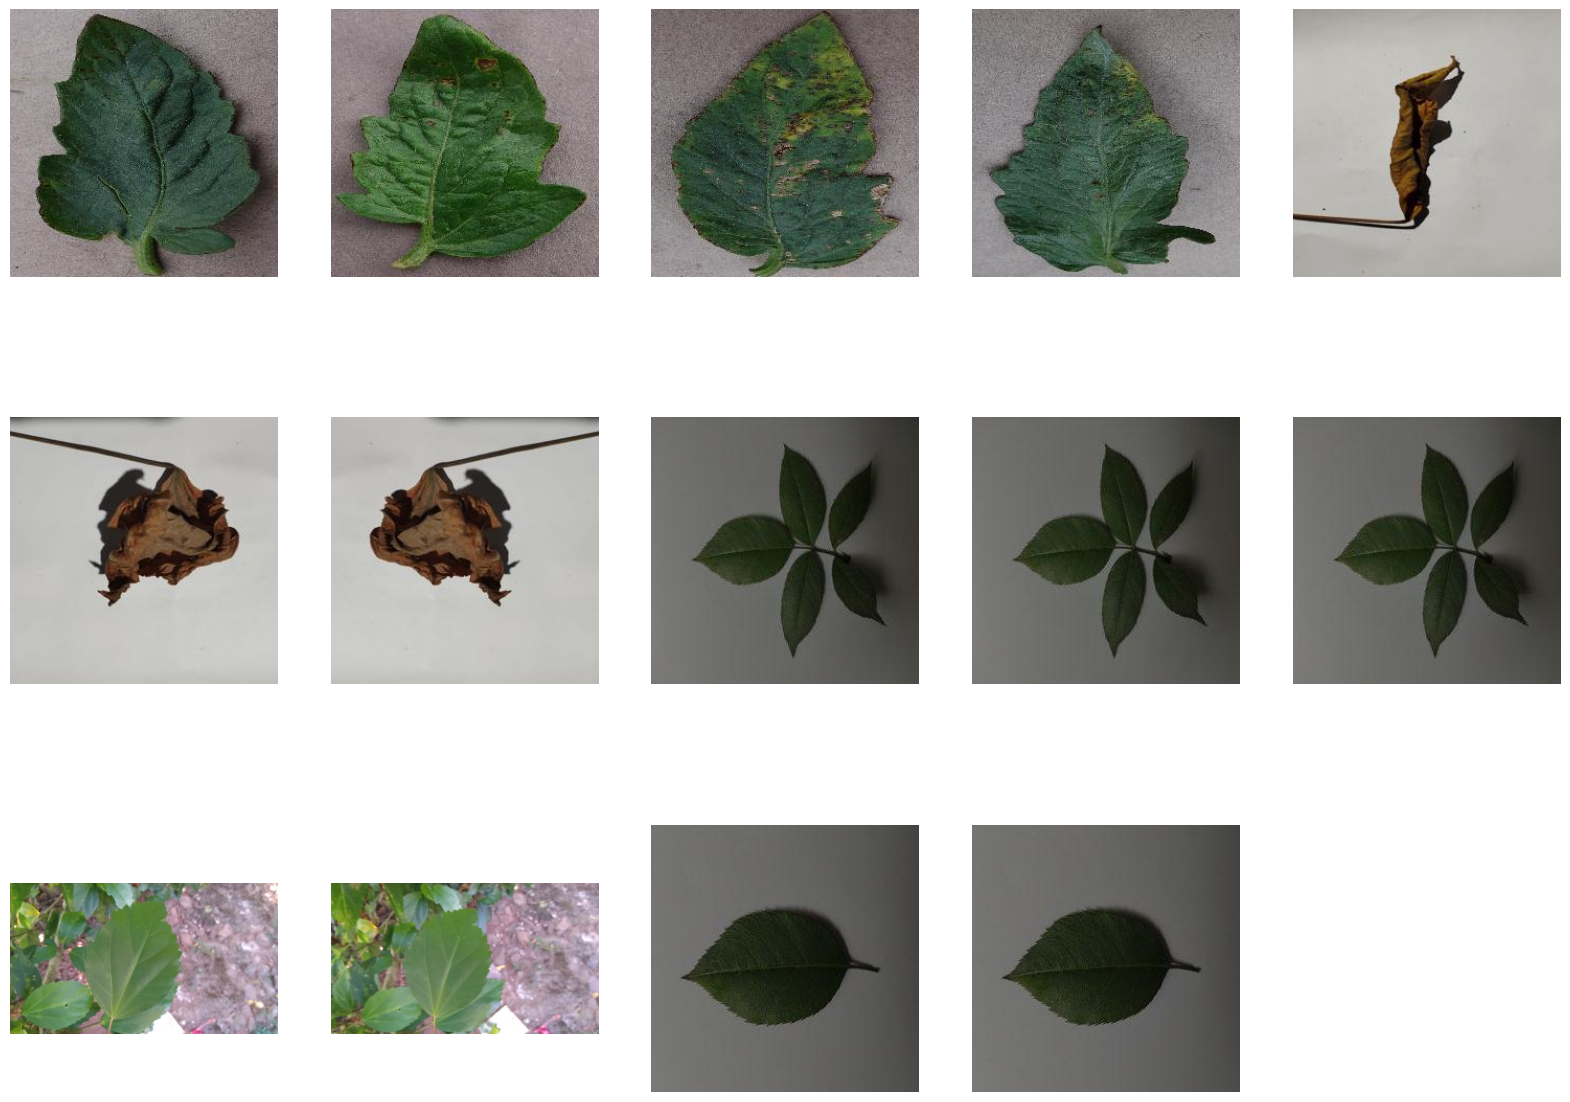

In [57]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms

# Define preprocessing
image_size = (256, 256)
preprocess = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Ensure mean/std are defined
])

# Load test images
test_folder = "/content/drive/MyDrive/test/test/test"

if not os.path.exists(test_folder):
    print("Error: Test folder not found!")
else:
    image_names = [f for f in os.listdir(test_folder) if os.path.isfile(os.path.join(test_folder, f))]
    print("Total images found:", len(image_names))

    if len(image_names) > 0:
        num_images = len(image_names)
        num_cols = 5
        num_rows = (num_images + num_cols - 1) // num_cols

        plt.figure(figsize=(20, 5 * num_rows))

        for i, img_name in enumerate(image_names):
            img_path = os.path.join(test_folder, img_name)
            img = Image.open(img_path).convert('RGB')
            plt.subplot(num_rows, num_cols, i + 1)
            plt.imshow(img)
            plt.axis('off')

        plt.show()
    else:
        print("No images to display!")


In [58]:
image_size = (256, 256)
preprocess = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)])

# Load and preprocess images
test_folder = '/content/drive/MyDrive/test/test/test'  # Path to the folder containing test images

# Get a list of image files, filtering out directories
image_names = [f for f in os.listdir(test_folder) if os.path.isfile(os.path.join(test_folder, f))]


# Plot predictions for all images
num_images = len(image_names)  # Total number of images
num_cols = 5  # Number of columns in the plot grid
num_rows = (num_images + num_cols - 1) // num_cols  # Calculate number of rows needed

plt.figure(figsize=(25, 5 * num_rows))  # Adjust figure size dynamically
for i, img_name in enumerate(image_names):
    img_path = os.path.join(test_folder, img_name)
    img = Image.open(img_path).convert('RGB')  # Ensure 3 channels
    img_tensor = preprocess(img).unsqueeze(0).to(device)  # Add batch dimension and move to device


    with torch.no_grad():
        predictions = saved_model(img_tensor)
    predicted_class_idx = torch.argmax(predictions, dim=1).item()  # Get predicted class index
    predicted_label = class_names[predicted_class_idx]  # Map to class name

    actual_class = img_name  # Assuming file name is the actual class
    # Plot the image with the actual and predicted labels
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
class_names[4],class_names[2]

('Gall Midge', 'Cutting Weevil')

In [ ]:
class_names[5],class_names[10]

('Cherry_(including_sour)_Powdery_mildew', 'Corn_(maize)_healthy')

### The model gets confused between these the most:
1) **Corn(maize)_cercospora_leaf_spot Gray_leaf_sopt** and **Corn(maize)_Northern_Leaf_Blight**
2) **Apple___Apple_scab** and **Apple___Black_rot**